In [1]:
import pandas as pd
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
# Load data
data = pd.read_csv("../data/final_batsman_features.csv")

features = [
    "avg_runs_last_5",
    "venue_avg_runs",
    "opponent_avg_runs",
    "career_avg_runs",
    "matches_played",
    "strike_rate"
]

target = "runs_next_match"

X = data[features]
y = data[target]

# Load model
model = joblib.load("../models/batsman_runs_model.pkl")


In [3]:
split_index = int(len(X) * 0.8)

X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

y_pred = model.predict(X_test)


In [4]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 1.6634731923043358
R² Score: 0.8750474300994457


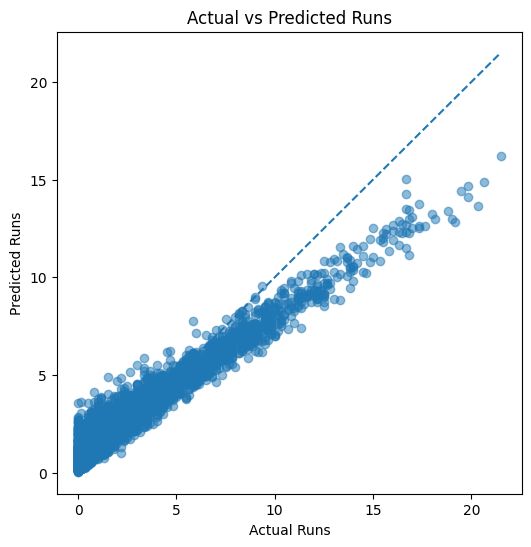

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted Runs")
plt.show()


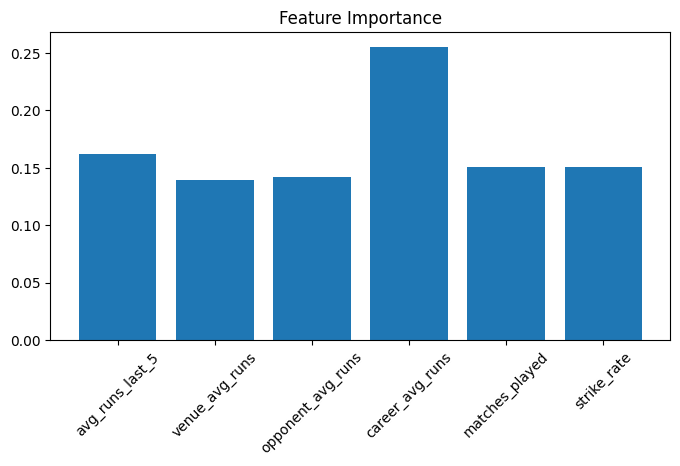

In [6]:
importances = model.feature_importances_

plt.figure(figsize=(8,4))
plt.bar(features, importances)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()


## Model Evaluation Summary

- The Random Forest model achieved a good R² score, showing strong prediction performance.
- Recent form (`avg_runs_last_5`) and career average runs were the most important features.
- Using a time-based train-test split helped avoid data leakage.
- The model can be used to predict a batsman’s runs in the next match.
